C:\Temp\ipykernel_25212\3325952053.py:4: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(image)
c:\Users\Shivraj Sarode\anaconda3\envs\Phelma\Lib\site-packages\skimage\io\_plugins\matplotlib_plugin.py:158: UserWarning: Low image data range; displaying image with stretched contrast.
  lo, hi, cmap = _get_display_range(image)


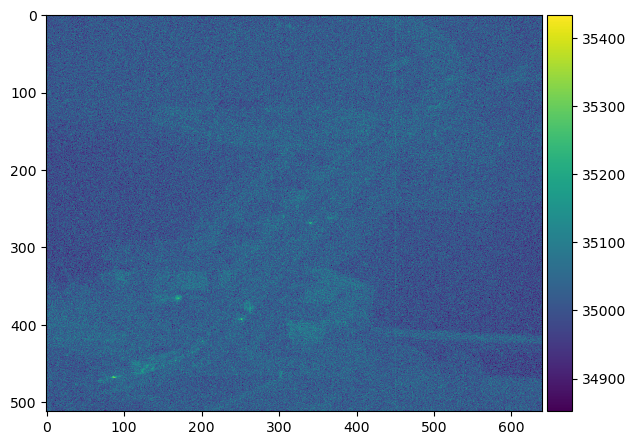

In [1]:
from skimage import io
import numpy as np
image=io.imread(r'C:\Users\Shivraj Sarode\Desktop\frame_0001.png')
io.imshow(image)

#### Normalisation min-max simple : image_8bit = (image_16bit - min) / (max - min) * 255

C:\Temp\ipykernel_25212\881963002.py:8: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(img_final)


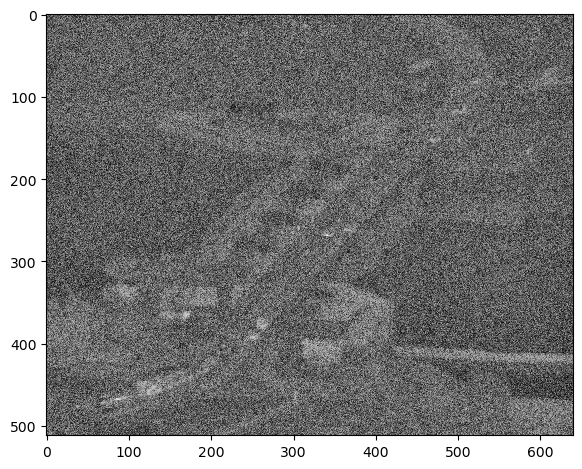

In [2]:
import cv2
import numpy as np

# Conversion nécessaire pour CLAHE (qui travaille en 8 bits)
img_8bit = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
img_final = clahe.apply(img_8bit)
io.imshow(img_final)

## To ckeck if the defect column width is one pixel wide or more

In [3]:
import cv2
import numpy as np

# Load as 16-bit (UNCHANGED)
img = cv2.imread(r'C:\Users\Shivraj Sarode\Desktop\frame_0001.png')
# print (img)

# Pick a row in the middle (e.g., row 100)
# Let's look at the area around column 150 (change this to your suspect column)
suspect_col = 470 
row_data = img[300, suspect_col-10 : suspect_col+10]
l = 0
defect_column = 468
defect = []
for l in range (512):
    defect.append((l,defect_column))
# print(f"Values around column {suspect_col}:")
print(row_data)
list_of_rows = []
print (defect[0])
for l in defect:
    list_of_rows.append(l[0])
print (list_of_rows)



[[136 136 136]
 [136 136 136]
 [136 136 136]
 [136 136 136]
 [136 136 136]
 [136 136 136]
 [136 136 136]
 [137 137 137]
 [136 136 136]
 [136 136 136]
 [136 136 136]
 [136 136 136]
 [136 136 136]
 [136 136 136]
 [136 136 136]
 [136 136 136]
 [136 136 136]
 [136 136 136]
 [136 136 136]
 [136 136 136]]
(0, 468)
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159,

## Now we know that for this image there is a defect on column 468. 

## For defect correction using mean

[(0, 468), (1, 468), (2, 468), (3, 468), (4, 468), (5, 468), (6, 468), (7, 468), (8, 468), (9, 468), (10, 468), (11, 468), (12, 468), (13, 468), (14, 468), (15, 468), (16, 468), (17, 468), (18, 468), (19, 468), (20, 468), (21, 468), (22, 468), (23, 468), (24, 468), (25, 468), (26, 468), (27, 468), (28, 468), (29, 468), (30, 468), (31, 468), (32, 468), (33, 468), (34, 468), (35, 468), (36, 468), (37, 468), (38, 468), (39, 468), (40, 468), (41, 468), (42, 468), (43, 468), (44, 468), (45, 468), (46, 468), (47, 468), (48, 468), (49, 468), (50, 468), (51, 468), (52, 468), (53, 468), (54, 468), (55, 468), (56, 468), (57, 468), (58, 468), (59, 468), (60, 468), (61, 468), (62, 468), (63, 468), (64, 468), (65, 468), (66, 468), (67, 468), (68, 468), (69, 468), (70, 468), (71, 468), (72, 468), (73, 468), (74, 468), (75, 468), (76, 468), (77, 468), (78, 468), (79, 468), (80, 468), (81, 468), (82, 468), (83, 468), (84, 468), (85, 468), (86, 468), (87, 468), (88, 468), (89, 468), (90, 468), (91, 468

(np.float64(-0.5), np.float64(639.5), np.float64(511.5), np.float64(-0.5))

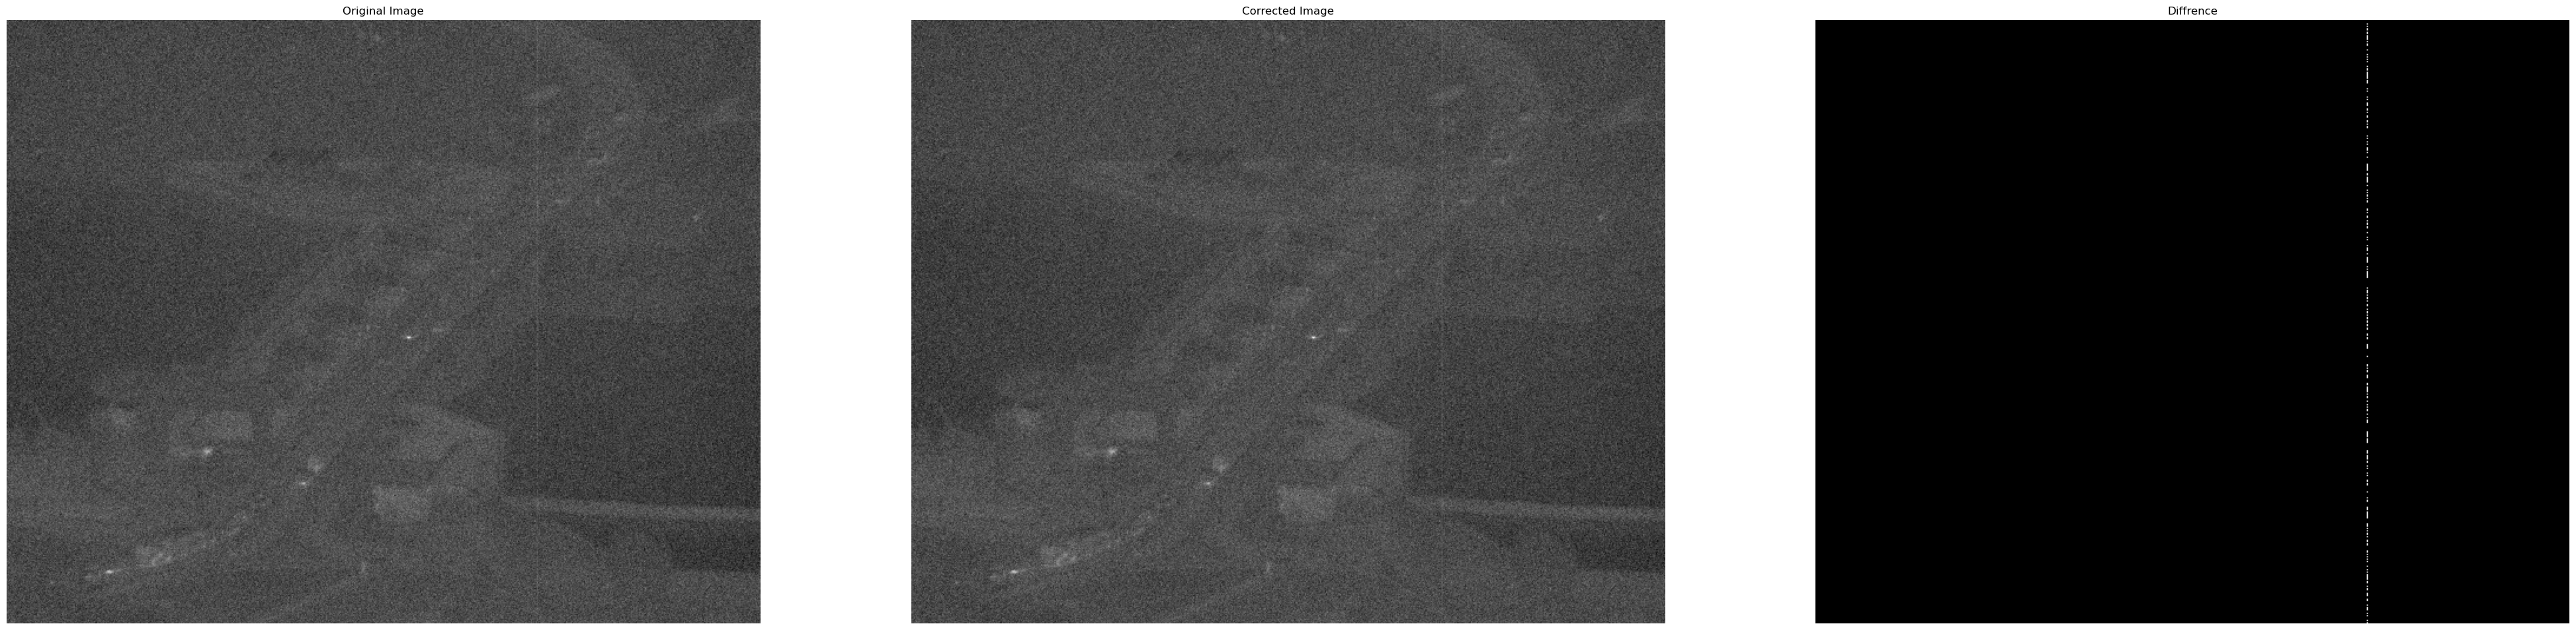

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load as 16-bit 
img = cv2.imread(r'C:\Users\Shivraj Sarode\Desktop\frame_0001.png',cv2.IMREAD_UNCHANGED)
# print (img)

defect_column = 468
defect = []
for l in range (512):
    defect.append((l,defect_column))

print (defect)
# print (img[0][0])

list_of_rows = []
for l in defect:
    list_of_rows.append(l[0])
print (list_of_rows)

def correct_defect(image, defects):
    '''
    defects = multiple array of defective pixels
    for current_defect in the defects array
        for defect[row] in image, 
            image [row:column] = (image [row:column+1] + image [row:column-1])/2
    
    ADD ANOTHER LOOP OVER THE ONE HERE FOR DEALING WITH MULTIPLE DEFECT COLUMNS
    '''
    copy_img = image.copy()
    for row in list_of_rows:
        copy_img [row,defect_column] = (copy_img [row,defect_column+1].astype(np.float32) + copy_img [row,defect_column-1].astype(np.float32))/2
    
    return copy_img

corr_img = correct_defect(img,defect)
diffrence = corr_img - img

fig, axs = plt.subplots(1, 3, figsize=(50, 30))
axs = axs.flatten()
axs[0].imshow(img, cmap='gray')
axs[0].set_title('Original Image')
axs[0].axis('off')
axs[1].imshow(corr_img, cmap='gray')
axs[1].set_title('Corrected Image')
axs[1].axis('off')
axs[2].imshow(diffrence, cmap='gray')
axs[2].set_title('Diffrence')
axs[2].axis('off')

In [5]:
import cv2
import os

# Define the desktop path dynamically for your computer
desktop = os.path.join(os.path.join(os.environ['USERPROFILE']), 'Desktop')
save_path = os.path.join(desktop, 'corrected_frame_2pixel.png')

# Save the image
# 'corr_img' is the variable from your previous code
success = cv2.imwrite(save_path, corr_img)

if success:
    print(f"File saved successfully to: {save_path}")
else:
    print("Error: Could not save the image.")

File saved successfully to: C:\Users\Shivraj Sarode\Desktop\corrected_frame_2pixel.png


## Using 6 surrounding pixels

[(0, 468), (1, 468), (2, 468), (3, 468), (4, 468), (5, 468), (6, 468), (7, 468), (8, 468), (9, 468), (10, 468), (11, 468), (12, 468), (13, 468), (14, 468), (15, 468), (16, 468), (17, 468), (18, 468), (19, 468), (20, 468), (21, 468), (22, 468), (23, 468), (24, 468), (25, 468), (26, 468), (27, 468), (28, 468), (29, 468), (30, 468), (31, 468), (32, 468), (33, 468), (34, 468), (35, 468), (36, 468), (37, 468), (38, 468), (39, 468), (40, 468), (41, 468), (42, 468), (43, 468), (44, 468), (45, 468), (46, 468), (47, 468), (48, 468), (49, 468), (50, 468), (51, 468), (52, 468), (53, 468), (54, 468), (55, 468), (56, 468), (57, 468), (58, 468), (59, 468), (60, 468), (61, 468), (62, 468), (63, 468), (64, 468), (65, 468), (66, 468), (67, 468), (68, 468), (69, 468), (70, 468), (71, 468), (72, 468), (73, 468), (74, 468), (75, 468), (76, 468), (77, 468), (78, 468), (79, 468), (80, 468), (81, 468), (82, 468), (83, 468), (84, 468), (85, 468), (86, 468), (87, 468), (88, 468), (89, 468), (90, 468), (91, 468

(np.float64(-0.5), np.float64(639.5), np.float64(511.5), np.float64(-0.5))

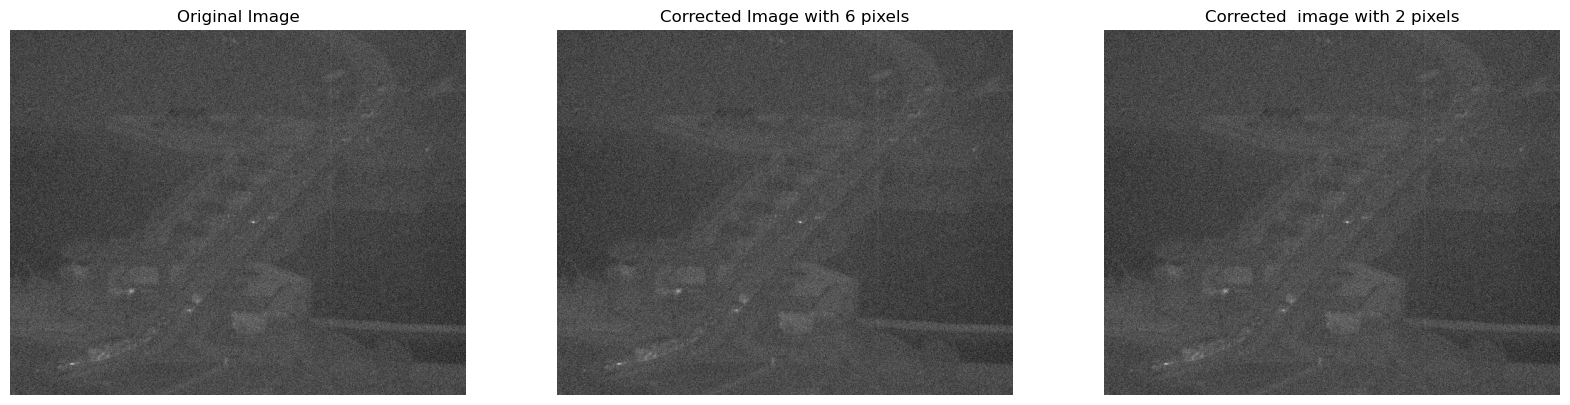

In [6]:
import cv2
import numpy as np

# Load as 16-bit 
img = cv2.imread(r'C:\Users\Shivraj Sarode\Desktop\frame_0001.png',cv2.IMREAD_UNCHANGED)
# print (img)

defect_column = 468
defect = []
for l in range (511):
    defect.append((l,defect_column))

print (defect)
# print (img[0][0])

list_of_rows = []
for l in defect:
    list_of_rows.append(l[0])
print (list_of_rows)

def correct_defect(image, defects):
    '''
    defects = multiple array of defective pixels
    for current_defect in the defects array
        for defect[row] in image, 
            image [row:column] = (image [row:column+1] + image [row:column-1])/2
    
    ADD ANOTHER LOOP OVER THE ONE HERE FOR DEALING WITH MULTIPLE DEFECT COLUMNS
    '''
    copy_img = image.copy()
    for row in list_of_rows:
        copy_img [row,defect_column] = (copy_img [row,defect_column+1].astype(np.float32) + copy_img [row,defect_column-1].astype(np.float32) 
                                        + copy_img [row+1,defect_column+1].astype(np.float32) + copy_img [row+1,defect_column-1].astype(np.float32)
                                        + copy_img [row-1,defect_column+1].astype(np.float32) + copy_img [row-1,defect_column-1].astype(np.float32))/6
    
    return copy_img

corr_img_6 = correct_defect(img,defect)
diffrence = corr_img - img

fig, axs = plt.subplots(1, 3, figsize=(20, 10))
axs = axs.flatten()
axs[0].imshow(img, cmap='gray')
axs[0].set_title('Original Image')
axs[0].axis('off')
axs[1].imshow(corr_img_6, cmap='gray')
axs[1].set_title('Corrected Image with 6 pixels')
axs[1].axis('off')
axs[2].imshow(corr_img, cmap='gray')
axs[2].set_title('Corrected  image with 2 pixels')
axs[2].axis('off')

In [31]:
import cv2
import os

# Define the desktop path dynamically for your computer
desktop = os.path.join(os.path.join(os.environ['USERPROFILE']), 'Desktop')
save_path = os.path.join(desktop, 'corrected_frame_6pixel.png')

# Save the image
# 'corr_img' is the variable from your previous code
success = cv2.imwrite(save_path, corr_img_6)

if success:
    print(f"File saved successfully to: {save_path}")
else:
    print("Error: Could not save the image.")

File saved successfully to: C:\Users\Shivraj Sarode\Desktop\corrected_frame_6pixel.png


In [7]:
# print (corr_img_6)

suspect_col = 470 
row_data = img[300, suspect_col-10 : suspect_col+10]
print(row_data)

[34992 35033 34976 34987 35039 34987 34984 35073 34989 34988 35006 34966
 34994 34996 34988 35044 35027 34987 34991 35036]


In [8]:
import os
import json
import cv2
import numpy as np
from pathlib import Path

def evaluate_single_image(img_without_defect, img_with_defect, img_eval_path, json_path=None):
    """
    Évalue une image corrigée en la comparant à l'originale (100%) et à la base défectueuse (0%).
    """

    # ==========================================
    # Fonctions utilitaires intégrées
    # ==========================================
    def read_json(p):
        p = Path(p)
        if not p.is_file():
            raise FileNotFoundError(f"Fichier introuvable : {p}")
        return json.loads(p.read_text(encoding="utf-8"))

    def process_json(data):
        indices = []
        for c in data:
            indices += c["x_coord"]
        return np.array(indices, dtype=int)

    def load_image(path):
        if not os.path.exists(path):
            raise FileNotFoundError(f"Image introuvable : {path}")
        return cv2.imread(path, -1).astype(np.float32, copy=False)

    # ==========================================
    # Chargement des images
    # ==========================================
    gt = load_image(img_without_defect)      # 100% Original (Ground Truth)
    base = load_image(img_with_defect)      # 0% Défectueux (Base)
    res = load_image(img_eval_path)    # Image à évaluer

    if gt.shape != base.shape or gt.shape != res.shape:
        raise ValueError("Les trois images doivent avoir exactement la même résolution.")

    nb_cols = gt.shape[1]

    # ==========================================
    # Calcul des erreurs globales pour la similarité
    # ==========================================
    # Erreur totale de l'image de base (non corrigée) par rapport au 100%
    diff_base_sq = ((base - gt) ** 2).sum(axis=0)
    ssd_base = diff_base_sq.sum()

    # Erreur totale de l'image évaluée (corrigée) par rapport au 100%
    residu_sq = ((res - gt) ** 2).sum(axis=0)
    ssd_eval = residu_sq.sum()

    # Calcul du niveau de similarité (0% = image base, 100% = image parfaite)
    if ssd_base > 0:
        similarite = 100.0 * (1.0 - (ssd_eval / ssd_base))
    else:
        similarite = 100.0  # Si l'image de base n'avait aucun défaut dès le départ

    # ==========================================
    # Identification des colonnes défectueuses
    # ==========================================
    if json_path and os.path.exists(json_path):
        true_def = process_json(read_json(json_path))
    else:
        true_def = np.flatnonzero(diff_base_sq)

    true_mask = np.isin(np.arange(nb_cols), true_def)

    # ==========================================
    # Évaluation de la détection (res)
    # ==========================================
    detected = np.flatnonzero(residu_sq)

    # Calcul des TP, FP, FN
    tp = np.intersect1d(detected, true_def, assume_unique=True).size
    fp = np.setdiff1d(detected, true_def, assume_unique=True).size
    fn = np.setdiff1d(true_def, detected, assume_unique=True).size

    mask_def = true_mask
    mask_ok  = ~true_mask

    sq_def = (residu_sq[mask_def]).sum()
    cnt_def = mask_def.sum() * gt.shape[0]

    sq_ok  = (residu_sq[mask_ok]).sum()
    cnt_ok = mask_ok.sum() * gt.shape[0]

    nb_cols_f = float(nb_cols)
    tp_norm = tp / nb_cols_f
    fp_norm = fp / nb_cols_f
    fn_norm = fn / nb_cols_f

    prec = tp_norm / (tp_norm + fp_norm) if (tp_norm + fp_norm) else 0.0
    rec  = tp_norm / (tp_norm + fn_norm) if (tp_norm + fn_norm) else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
    
    rmse_def = np.sqrt(sq_def / cnt_def) if cnt_def else 0.0
    rmse_ok  = np.sqrt(sq_ok  / cnt_ok ) if cnt_ok  else 0.0

    # Retourner les résultats (j'ai enlevé les anciens RMSE normalisés qui ne te servent plus)
    return {
        "TP_norm": round(tp_norm, 6),
        "FP_norm": round(fp_norm, 6),
        "FN_norm": round(fn_norm, 6),
        "Precision": round(prec, 6),
        "Recall": round(rec, 6),
        "F1_Score": round(f1, 6),
        "RMSE_def": round(rmse_def, 6),
        "RMSE_ok": round(rmse_ok, 6),
        "Similarite_GT_pct": round(similarite, 2) # Arrondi à 2 décimales pour faire "pourcentage"
    }

def print_metrics_table(metrics):
    """
    Affiche un dictionnaire de métriques sous la forme d'un tableau formaté dans la console.
    """
    col_metrique = 20
    col_valeur = 12
    ligne_separatrice = "+" + "-" * (col_metrique + 2) + "+" + "-" * (col_valeur + 2) + "+"
    
    print("\nRÉSULTATS DE L'ÉVALUATION")
    print(ligne_separatrice)
    print(f"| {'Métrique'.ljust(col_metrique)} | {'Valeur'.rjust(col_valeur)} |")
    print(ligne_separatrice)
    
    for key, value in metrics.items():
        if key == "Similarite_GT_pct":
            print(ligne_separatrice)
            formatted_value = f"{value:.2f} %"
        else:
            formatted_value = f"{value:.6f}" if isinstance(value, float) else str(value)
            
        print(f"| {key.ljust(col_metrique)} | {formatted_value.rjust(col_valeur)} |")
        
    print(ligne_separatrice)

In [9]:
if __name__ == "__main__":
    resultats = evaluate_single_image(
        img_without_defect=r'C:\Users\Shivraj Sarode\Desktop\DC_Pics\train\VGA\sequence_1\low dyn\frame_0001.png',
        img_with_defect=r'C:\Users\Shivraj Sarode\Desktop\DC_Pics\train\VGA\sequence_1\low dyn with columns 1\frame_0001.png',
        img_eval_path=r'C:\Users\Shivraj Sarode\Desktop\corrected_frame_6pixel.png'
    )

    print(f"\nNiveau de similarité avec l'image parfaite : {resultats['Similarite_GT_pct']} %")
    print_metrics_table(resultats)


Niveau de similarité avec l'image parfaite : -89.25 %

RÉSULTATS DE L'ÉVALUATION
+----------------------+--------------+
| Métrique             |       Valeur |
+----------------------+--------------+
| TP_norm              |     0.003125 |
| FP_norm              |     0.001563 |
| FN_norm              |     0.000000 |
| Precision            |     0.666667 |
| Recall               |     1.000000 |
| F1_Score             |     0.800000 |
| RMSE_def             |    23.926972 |
| RMSE_ok              |     1.265624 |
+----------------------+--------------+
| Similarite_GT_pct    |     -89.25 % |
+----------------------+--------------+


(np.float64(-0.5), np.float64(639.5), np.float64(511.5), np.float64(-0.5))

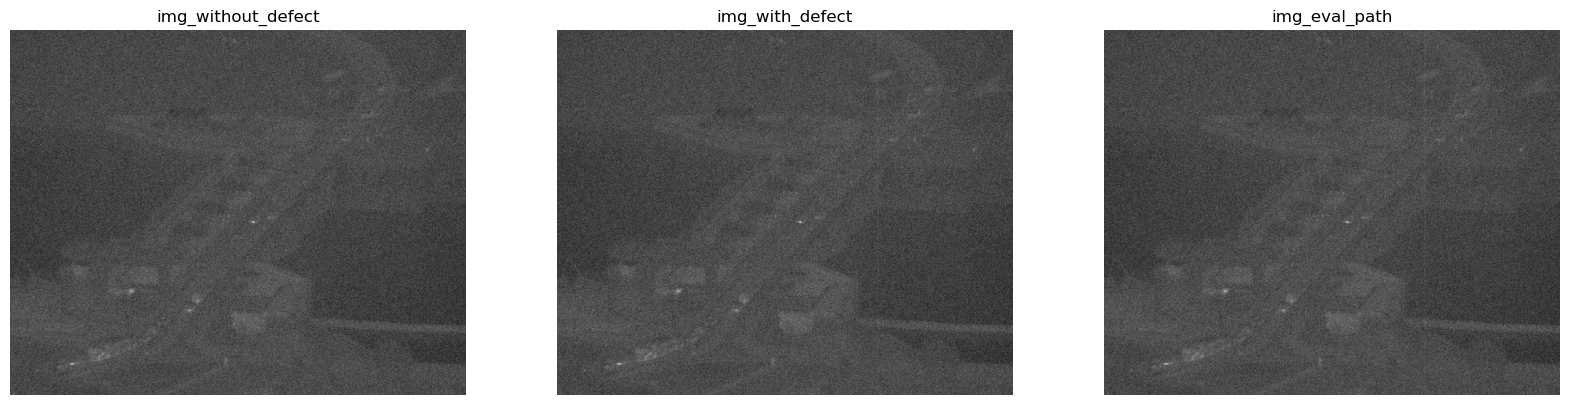

In [10]:
img_without_defect = io.imread(r'C:\Users\Shivraj Sarode\Desktop\DC_Pics\train\VGA\sequence_1\low dyn\frame_0001.png')
img_with_defect = io.imread(r'C:\Users\Shivraj Sarode\Desktop\DC_Pics\train\VGA\sequence_1\low dyn with columns 1\frame_0001.png')
img_eval_path = io.imread(r'C:\Users\Shivraj Sarode\Desktop\corrected_frame_6pixel.png')
fig, axs = plt.subplots(1, 3, figsize=(20, 10))
axs = axs.flatten()
axs[0].imshow(img_without_defect, cmap='gray')
axs[0].set_title('img_without_defect')
axs[0].axis('off')
axs[1].imshow(img_with_defect, cmap='gray')
axs[1].set_title('img_with_defect')
axs[1].axis('off')
axs[2].imshow(img_eval_path, cmap='gray')
axs[2].set_title('img_eval_path')
axs[2].axis('off')